# 선형 회귀

### 데이터 불러오기

In [ ]:
# 데이터 불러오기
from sklearn.datasets import load_diabetes
import pandas as pd

diab = load_diabetes()
data = pd.DataFrame(data=diab.data, columns=diab.feature_names)

### 간단 EDA

In [ ]:
# 어떤 칼럼이 있는가?
# 결측값이 있는가?
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
dtypes: float64(10)
memory usage: 34.7 KB


In [ ]:
# 컬럼 별 값의 예시는?
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


In [ ]:
# 값의 범위나 분포는?
data.describe()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01


### DataFrame으로 변환해야 하는 이유ㅜ.ㅜ

**AttributeError** 발생
- 파이썬에서 객체(Object)에 존재하지 않는 속성(attribute)이나 메서드(method)에 접근하려고 할 때 발생하는 오류
-  "이 객체에는 네가 찾는 기능이 없어!"라는 뜻ㅜㅜ

---

EDA에서 사용한 info(), head(), describe()의 분석 함수는 Pandas의 DataFrame에서만 사용 가능한 **전용 함수**

In [ ]:
diab.info()

AttributeError: info

In [ ]:
diab.head()

AttributeError: head

In [ ]:
diab.describe()

AttributeError: describe

### 참고용 (몰라도 됩니다)

**Bunch = 사이킷런 전용 객체**
- 여러 종류의 데이터를 하나로 묶어둔 객체(Container)
- 넘파이 배열(data, target)들을 보기 좋게 모아놓은 보따리


---
*diab = load_diabetes()*

를 통해서 당뇨병 데이터셋을 가지고 왔죠?

=> diab는 Bunch 타입의 데이터셋입니다.

---
**그럼 왜 DataFrame으로 변환해야 하나요?**

EDA에서 사용한 함수 (info, head, describe)들은 DataFrame 전용 객체라고 했었죠?

예를 들어,
- Pandas의 DataFrame = 이미 개봉한 택배
- sklearn의 Bunch = 미개봉 택배

라고 한다면, EDA 함수들은 "택배 안에 뭐가 들어있었어?" 라는 질문과 같아요

.........

DataFrame(개봉한 택배)에 뭐가 들어있었어??   →   아 나 저번에 시킨 화장품 배달왔더랑

Bunch(미개봉 택배)에 뭐가 들어있었어??   → 안열어봤는데 그걸 내가 어떻게 알아?? (황당)

그래서 오류가 발생합니다

**Bunch의 주요 속성에는 뭐가 있나요?**

- .data() = 설명 변수
- .target() = 타깃 변수
- feature_names() = 컬럼명


### 설명변수와 타깃변수 분리

In [ ]:
# 독립변수(설명변수)와 종속변수(타깃변수) 분리
X = pd.DataFrame(diab.data, columns=diab.feature_names)
y = pd.Series(diab.target, name='target')

In [ ]:
# BMI를 통한 당뇨 진행도 예측
# 훈련, 테스트 데이터 분리
from sklearn.model_selection import train_test_split

# bmi 칼럼만 선택
X_bmi = X[['bmi']]
X_train, X_test, y_train, y_test = train_test_split(X_bmi, y, random_state=42)

### (드디어!) 선형 회귀를 해봅시다

In [ ]:
# 선형 회귀 모델 불러오기 및 모델 학습시키기
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

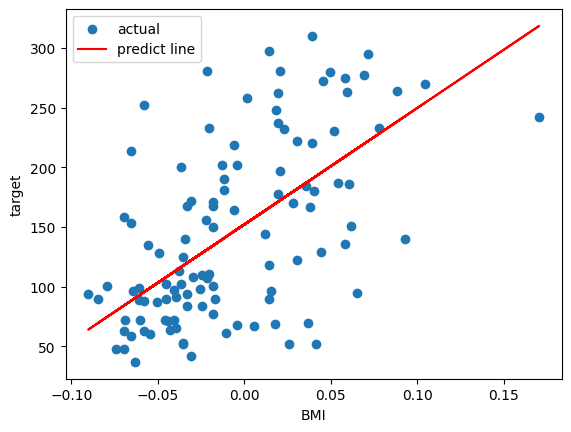

Coef: 975.2769831271274 Intercept: 152.07653296894014


In [ ]:
# y값 예측해보기
# 실제 데이터와 예측선 시각화
import matplotlib.pyplot as plt

y_pred = lr.predict(X_test)

plt.scatter(X_test, y_test, label='actual')
plt.plot(X_test, y_pred, color='red', label='predict line')
plt.xlabel('BMI')
plt.ylabel('target')
plt.legend()
plt.show()

print('Coef:', lr.coef_[0], 'Intercept:', lr.intercept_)

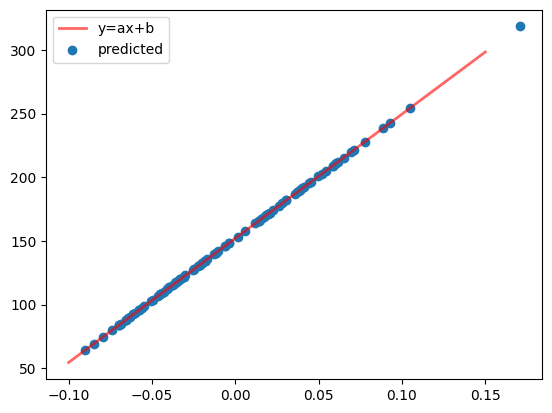

In [ ]:
# 예측 데이터와 예측선 시각화
import numpy as np
a = lr.coef_[0]
b = lr.intercept_

x = np.linspace(-0.10,0.15)
y = a*x+b

plt.plot(x, y, color='red', linewidth=2, alpha=0.6, label='y=ax+b')
plt.scatter(X_test, y_pred, label='predicted')
plt.legend()
plt.show()

# 캐글 데이터

In [ ]:
#라이브러리 호출
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, LabelEncoder
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV

In [ ]:
#데이터 불러오기
df = pd.read_csv('kaggle_data.csv')
df.head(5)

,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [ ]:
df['product'].unique()

array(['Holographic Goose', 'Kaggle', 'Kaggle Tiers', 'Kerneler',
       'Kerneler Dark Mode'], dtype=object)

In [ ]:
df['country'].unique()

array(['Canada', 'Finland', 'Italy', 'Kenya', 'Norway', 'Singapore'],
      dtype=object)

In [ ]:
df['store'].unique()

array(['Discount Stickers', 'Stickers for Less', 'Premium Sticker Mart'],
      dtype=object)

In [ ]:
#데이터 파악하기
def simple_summary(df):
    print("\n" + "="*50)
    print(f"       [ DATASET SUMMARY ]")
    print("="*50)
    print(f"▶ Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("-"*50)
    print(f"{'Column Name':<20} | {'Dtype':<10} | {'Nulls'}")
    print("-"*50)

    for col in df.columns:
        null_count = df[col].isnull().sum()
        dtype = str(df[col].dtype)
        # 결측치가 있으면 강조(★) 표시
        null_str = f"{null_count} (!!)" if null_count > 0 else f"{null_count}"
        print(f"{col[:20]:<20} | {dtype:<10} | {null_str}")

    print("="*50 + "\n")

# 사용 예시
simple_summary(df)


       [ DATASET SUMMARY ]
▶ Shape: 230130 rows, 6 columns
--------------------------------------------------
Column Name          | Dtype      | Nulls
--------------------------------------------------
id                   | int64      | 0
date                 | object     | 0
country              | object     | 0
store                | object     | 0
product              | object     | 0
num_sold             | float64    | 8871 (!!)



In [ ]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

In [ ]:
categorical_cols = ['country', 'store', 'product','date']

# 2. LabelEncoder 적용
le = LabelEncoder()

for col in categorical_cols:
    # 각 컬럼별로 학습 및 변환
    df[col] = le.fit_transform(df[col])
    print(f"✅ {col:<10} 변환 완료")

print("\n" + "="*30)
print(df[categorical_cols].dtypes)

✅ country    변환 완료
✅ store      변환 완료
✅ product    변환 완료
✅ date       변환 완료

country    int64
store      int64
product    int64
date       int64
dtype: object


In [ ]:
df = df.dropna(subset=['num_sold'])

X=df.drop(["num_sold"],axis=1)
y=df["num_sold"]

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=33)

In [ ]:
rf = RandomForestRegressor(random_state=33, n_jobs=-1)

# 2. 하이퍼파라미터 그리드 (학습 속도를 위해 가볍게 설정)
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 4]
}

# 3. GridSearchCV 설정 (MAPE 기준)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error', # MAPE 기준
    verbose=2
)

# 4. 학습 시작
print("🚀 MAPE 기준으로 GridSearchCV 최적화 시작...")
grid_search.fit(X_train, y_train)

# 5. 예측 및 최종 MAPE 계산
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

# 실제 MAPE (0.1이면 10% 오차를 의미)
final_mape = mean_absolute_percentage_error(y_test, y_pred)

print("\n" + "="*50)
print(f"✅ 최적 파라미터: {grid_search.best_params_}")
print(f"📊 최종 검증 MAPE: {final_mape:.4f} ({final_mape*100:.2f}%)")
print("="*50)

🚀 MAPE 기준으로 GridSearchCV 최적화 시작...
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  19.3s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.0s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  16.0s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  16.5s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  16.1s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  16.5s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  21.7s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  22.0s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  21.9s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=  21.6s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=  22.6s
[CV] END max_d

## 성능 개선(팀과제)

In [ ]:
# ============================================================
# 1. 데이터 불러오기
# ============================================================

df = pd.read_csv('kaggle_data.csv')

print(df.shape)
display(df.head())

(230130, 6)


,id,date,country,store,product,num_sold
0,0,2010-01-01,Canada,Discount Stickers,Holographic Goose,NaN
1,1,2010-01-01,Canada,Discount Stickers,Kaggle,973.0
2,2,2010-01-01,Canada,Discount Stickers,Kaggle Tiers,906.0
3,3,2010-01-01,Canada,Discount Stickers,Kerneler,423.0
4,4,2010-01-01,Canada,Discount Stickers,Kerneler Dark Mode,491.0


In [ ]:
# ============================================================
# 2. 결측값 제거
# ============================================================

df = df.dropna(subset=['num_sold']).copy()

print(df.isnull().sum())

id          0
date        0
country     0
store       0
product     0
num_sold    0
dtype: int64


In [ ]:
# ============================================================
# 3. 날짜 특성 생성
# ============================================================

df['date'] = pd.to_datetime(df['date'])

# 기본 날짜 특성
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofweek'] = df['date'].dt.dayofweek
df['dayofyear'] = df['date'].dt.dayofyear
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter

# 주말 여부
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

# 월초, 월말 여부
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# 연초, 연말 여부
df['is_year_start'] = df['date'].dt.is_year_start.astype(int)
df['is_year_end'] = df['date'].dt.is_year_end.astype(int)

# 전체 기간에서 날짜가 얼마나 지났는지
df['days_since_start'] = (
    df['date'] - df['date'].min()
).dt.days

In [ ]:
# ============================================================
# 4. 계절성을 표현하는 주기형 변수
# ============================================================

# 월 단위 계절성
df['month_sin'] = np.sin(
    2 * np.pi * df['month'] / 12
)

df['month_cos'] = np.cos(
    2 * np.pi * df['month'] / 12
)

# 요일 단위 계절성
df['dayofweek_sin'] = np.sin(
    2 * np.pi * df['dayofweek'] / 7
)

df['dayofweek_cos'] = np.cos(
    2 * np.pi * df['dayofweek'] / 7
)

# 연 단위 계절성
df['dayofyear_sin'] = np.sin(
    2 * np.pi * df['dayofyear'] / 365.25
)

df['dayofyear_cos'] = np.cos(
    2 * np.pi * df['dayofyear'] / 365.25
)

In [ ]:
# ============================================================
# 5. 범주형 변수 조합 생성
# ============================================================

# 개별 범주만 사용하는 것보다 조합 특성이 판매량 차이를
# 더 쉽게 구분하도록 도와줄 수 있음

df['country_store'] = (
    df['country'].astype(str)
    + '_'
    + df['store'].astype(str)
)

df['country_product'] = (
    df['country'].astype(str)
    + '_'
    + df['product'].astype(str)
)

df['store_product'] = (
    df['store'].astype(str)
    + '_'
    + df['product'].astype(str)
)

df['country_store_product'] = (
    df['country'].astype(str)
    + '_'
    + df['store'].astype(str)
    + '_'
    + df['product'].astype(str)
)

In [ ]:
# ============================================================
# 6. Label Encoding
# ============================================================

categorical_cols = [
    'country',
    'store',
    'product',
    'country_store',
    'country_product',
    'store_product',
    'country_store_product'
]

label_encoders = {}

for col in categorical_cols:
    encoder = LabelEncoder()

    df[col] = encoder.fit_transform(
        df[col].astype(str)
    )

    label_encoders[col] = encoder

    print(f'{col:<25} 변환 완료')

country                   변환 완료
store                     변환 완료
product                   변환 완료
country_store             변환 완료
country_product           변환 완료
store_product             변환 완료
country_store_product     변환 완료


In [ ]:
# ============================================================
# 7. 날짜 원본과 id 제거
# ============================================================

# date는 이미 여러 날짜 파생변수로 변환했으므로 삭제
df = df.drop(columns=['date'])

# id는 단순 행 식별자일 가능성이 높으므로 학습에서 제외
if 'id' in df.columns:
    df = df.drop(columns=['id'])

display(df.head())

,country,store,product,num_sold,year,month,day,dayofweek,dayofyear,weekofyear,...,month_sin,month_cos,dayofweek_sin,dayofweek_cos,dayofyear_sin,dayofyear_cos,country_store,country_product,store_product,country_store_product
1,0,0,1,973.0,2010,1,1,4,1,53,...,0.5,0.866025,-0.433884,-0.900969,0.017202,0.999852,0,1,1,0
2,0,0,2,906.0,2010,1,1,4,1,53,...,0.5,0.866025,-0.433884,-0.900969,0.017202,0.999852,0,2,2,1
3,0,0,3,423.0,2010,1,1,4,1,53,...,0.5,0.866025,-0.433884,-0.900969,0.017202,0.999852,0,3,3,2
4,0,0,4,491.0,2010,1,1,4,1,53,...,0.5,0.866025,-0.433884,-0.900969,0.017202,0.999852,0,4,4,3
5,0,2,0,300.0,2010,1,1,4,1,53,...,0.5,0.866025,-0.433884,-0.900969,0.017202,0.999852,2,0,10,9


In [ ]:
# ============================================================
# 8. 입력 변수와 정답 분리
# ============================================================

X = df.drop(
    columns=['num_sold']
)

y = df['num_sold']

print('입력 데이터 크기:', X.shape)
print('정답 데이터 크기:', y.shape)
print('사용 변수:', X.columns.tolist())

입력 데이터 크기: (221259, 26)
정답 데이터 크기: (221259,)
사용 변수: ['country', 'store', 'product', 'year', 'month', 'day', 'dayofweek', 'dayofyear', 'weekofyear', 'quarter', 'is_weekend', 'is_month_start', 'is_month_end', 'is_year_start', 'is_year_end', 'days_since_start', 'month_sin', 'month_cos', 'dayofweek_sin', 'dayofweek_cos', 'dayofyear_sin', 'dayofyear_cos', 'country_store', 'country_product', 'store_product', 'country_store_product']


In [ ]:
# ============================================================
# 9. 학습 데이터와 검증 데이터 분리
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=33
)

print('학습 데이터:', X_train.shape)
print('검증 데이터:', X_test.shape)

학습 데이터: (177007, 26)
검증 데이터: (44252, 26)


In [ ]:
# ============================================================
# 10. 기존 RandomForest와 하이퍼파라미터 그대로 사용
# ============================================================

rf = RandomForestRegressor(
    random_state=33,
    n_jobs=-1
)

# 기존 하이퍼파라미터 변경 없음
param_grid = {
    'n_estimators': [100],
    'max_depth': [10, 15],
    'min_samples_split': [2, 4]
}

In [ ]:
# ============================================================
# 11. 기존 GridSearchCV 그대로 사용
# ============================================================

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='neg_mean_absolute_percentage_error',
    verbose=2
)

print('MAPE 기준 GridSearchCV 시작')

grid_search.fit(
    X_train,
    y_train
)

MAPE 기준 GridSearchCV 시작
Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  36.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  37.7s
[CV] END max_depth=10, min_samples_split=2, n_estimators=100; total time=  38.0s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  39.3s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  37.9s
[CV] END max_depth=10, min_samples_split=4, n_estimators=100; total time=  37.4s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  55.8s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  54.8s
[CV] END max_depth=15, min_samples_split=2, n_estimators=100; total time=  54.1s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=  55.8s
[CV] END max_depth=15, min_samples_split=4, n_estimators=100; total time=  54.7s
[CV] END max_depth=15, mi

GridSearchCV(cv=3, estimator=RandomForestRegressor(n_jobs=-1, random_state=33),
             param_grid={'max_depth': [10, 15], 'min_samples_split': [2, 4],
                         'n_estimators': [100]},
             scoring='neg_mean_absolute_percentage_error', verbose=2)

In [ ]:
# ============================================================
# 12. 예측 및 성능 평가
# ============================================================

best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(
    X_test
)

# 판매량이 음수가 되는 것을 방지
y_pred = np.maximum(
    y_pred,
    0
)

final_mape = mean_absolute_percentage_error(
    y_test,
    y_pred
)

print('=' * 50)
print('최적 파라미터:', grid_search.best_params_)
print(f'최종 검증 MAPE: {final_mape:.4f}')
print(f'최종 검증 MAPE: {final_mape * 100:.2f}%')
print('=' * 50)

최적 파라미터: {'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
최종 검증 MAPE: 0.0497
최종 검증 MAPE: 4.97%


In [ ]:
# ============================================================
# 13. 실제값과 예측값 비교
# ============================================================

result = pd.DataFrame({
    'actual': y_test.to_numpy(),
    'predicted': y_pred
})

result['absolute_error'] = np.abs(
    result['actual'] - result['predicted']
)

display(result.head(20))

,actual,predicted,absolute_error
0,565.0,562.411452,2.588548
1,264.0,255.983186,8.016814
2,1359.0,1107.666155,251.333845
3,1557.0,1576.702497,19.702497
4,987.0,1043.220679,56.220679
5,192.0,206.509284,14.509284
6,1322.0,1256.080750,65.919250
7,759.0,690.390044,68.609956
8,173.0,174.458054,1.458054
9,957.0,969.655074,12.655074


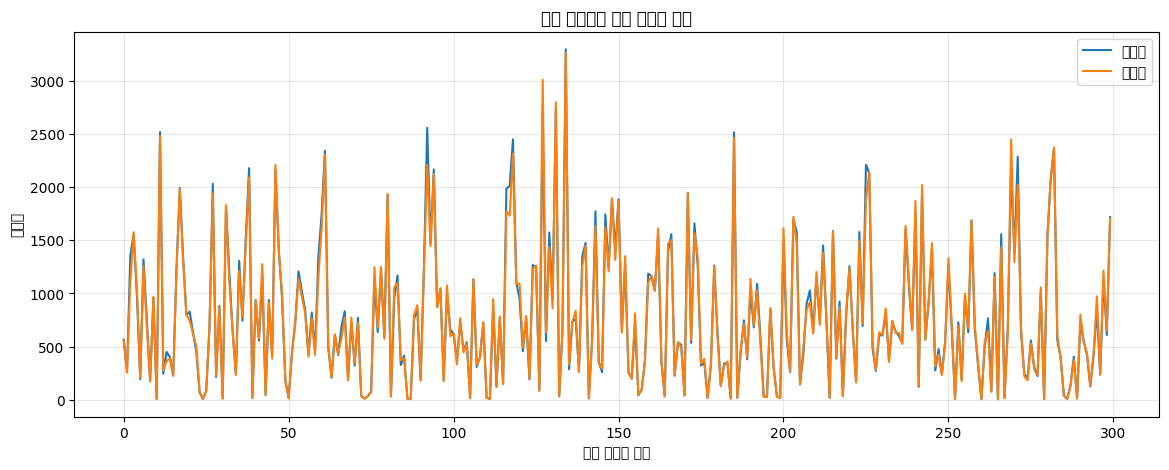

In [ ]:
# ============================================================
# 14. 실제값과 예측값 그래프
# ============================================================

plt.rc('font', family='NanumBarunGothic')

graph_data = result.iloc[:300]

plt.figure(figsize=(14, 5))

plt.plot(
    graph_data['actual'].to_numpy(),
    label='실제값'
)

plt.plot(
    graph_data['predicted'].to_numpy(),
    label='예측값'
)

plt.title('실제 판매량과 예측 판매량 비교')
plt.xlabel('검증 데이터 순서')
plt.ylabel('판매량')
plt.legend()
plt.grid(alpha=0.3)
plt.show()